In [1]:
import polars as pl

C:\Users\MSI BRAVO\AppData\Local\Temp\ipykernel_36048\1777859107.py:25: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("time_in_shelter_days").map_elements(lambda x: ...)
with this one instead:
  + pl.col("time_in_shelter_days").log1p()

  pl.col("time_in_shelter_days").map_elements(lambda x: np.log1p(x), return_dtype=pl.Float64).alias("target_log")


Volumen de Entrenamiento (Pre-2017): 56457 registros
Volumen de Validación (Post-2017): 19500 registros


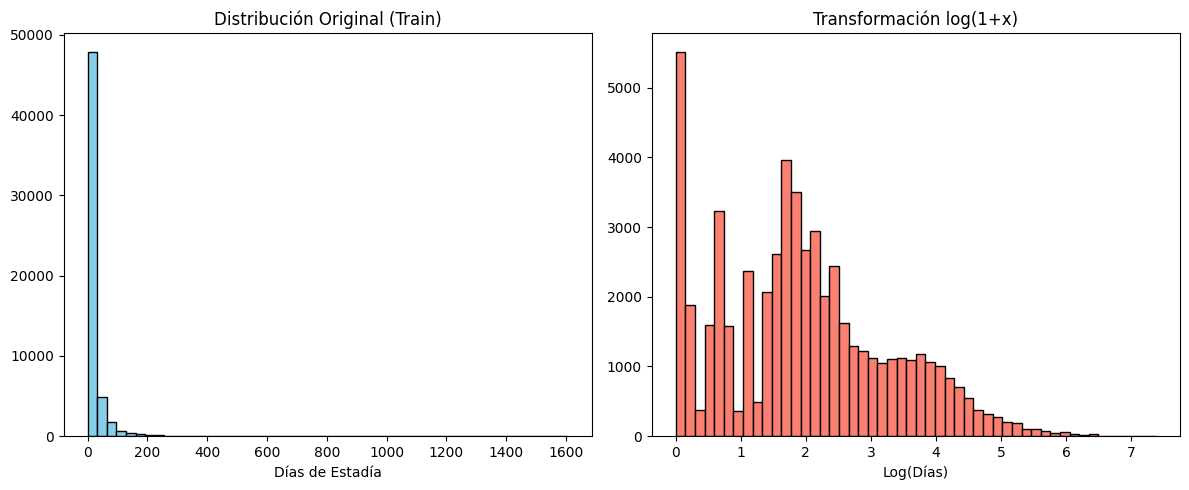

In [2]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carga de datos
df = pl.read_csv("aac_intakes_outcomes.csv")

# 2. Filtrado de Fuga de Datos (Data Leakage) y Población Objetivo
# Conservamos exclusivamente los ingresos válidos para el flujo operativo
valid_intakes = ['Stray', 'Owner Surrender', 'Public Assist']
df_filtered = df.filter(pl.col("intake_type").is_in(valid_intakes))

# 3. Extracción de Heurísticas (Feature Engineering Inicial)
# Transformamos la variable 'breed' extrayendo banderas lógicas de mestizaje y razas específicas
df_features = df_filtered.with_columns([
    pl.col("breed").str.to_lowercase().str.contains("mix").cast(pl.Int8).alias("is_mix"),
    pl.col("breed").str.to_lowercase().str.contains("pit bull").cast(pl.Int8).alias("is_pitbull"),
    # Formateo de fecha para el split temporal
    pl.col("intake_datetime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S")
])

# 4. Transformación Logarítmica de la Variable Objetivo
df_features = df_features.with_columns(
    pl.col("time_in_shelter_days").map_elements(lambda x: np.log1p(x), return_dtype=pl.Float64).alias("target_log")
)

# 5. Partición Temporal (Temporal Split)
# Entrenamos con datos históricos hasta finales de 2016 y probamos con el futuro (2017 en adelante)
cutoff_date = pl.datetime(2017, 1, 1)

train = df_features.filter(pl.col("intake_datetime") < cutoff_date)
test = df_features.filter(pl.col("intake_datetime") >= cutoff_date)

print(f"Volumen de Entrenamiento (Pre-2017): {train.height} registros")
print(f"Volumen de Validación (Post-2017): {test.height} registros")

# 6. Conversión a Pandas exclusiva para graficado analítico
train_pd = train.select(["time_in_shelter_days", "target_log"]).to_pandas()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_pd['time_in_shelter_days'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribución Original (Train)")
plt.xlabel("Días de Estadía")

plt.subplot(1, 2, 2)
plt.hist(train_pd['target_log'], bins=50, color='salmon', edgecolor='black')
plt.title("Transformación log(1+x)")
plt.xlabel("Log(Días)")

plt.tight_layout()
plt.show()

In [3]:
import polars as pl
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Asumimos que 'train' y 'test' ya existen desde el bloque anterior de Polars
# Para Scikit-Learn, extraemos las matrices a Pandas/Numpy
features_categoricas = ['animal_type', 'intake_type', 'intake_condition', 'sex_upon_intake']
features_numericas = ['age_upon_intake_(years)', 'is_mix', 'is_pitbull']

# Preparamos las matrices de entrenamiento y validación
X_train = train.select(features_categoricas + features_numericas).to_pandas()
y_train = train.select("target_log").to_series().to_numpy()

X_test = test.select(features_categoricas + features_numericas).to_pandas()
# Necesitamos el 'target' original sin logaritmo para medir el error real en días
y_test_real = test.select("time_in_shelter_days").to_series().to_numpy()

# 1. Construcción del Motor de Transformación (El "ETL" del Modelo)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Vital para ignorar razas/colores nuevos en test
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_numericas),
        ('cat', categorical_transformer, features_categoricas)
    ])

# 2. Ensamblaje del Pipeline Predictivo Base
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 3. Entrenamiento
baseline_model.fit(X_train, y_train)

# 4. Inferencia y Reversión de la Función Logarítmica
# El modelo predice en logaritmo, aplicamos exp(x)-1 para devolverlo a días físicos
y_pred_log = baseline_model.predict(X_test)
y_pred_real = np.expm1(y_pred_log) 

# 5. Evaluación de la Métrica Base
medae_base = median_absolute_error(y_test_real, y_pred_real)
rmse_base = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("=== RESULTADOS DEL MODELO BASE (Regresión Lineal Múltiple) ===")
print(f"MedAE (Error Absoluto Mediano): {medae_base:.2f} días")
print(f"RMSE (Error Cuadrático Medio): {rmse_base:.2f} días")

=== RESULTADOS DEL MODELO BASE (Regresión Lineal Múltiple) ===
MedAE (Error Absoluto Mediano): 4.48 días
RMSE (Error Cuadrático Medio): 28.31 días


In [6]:
import polars as pl
import numpy as np
import pandas as pd
from xgboost import XGBRegressor # Si usas el entorno local
# from sklearn.ensemble import HistGradientBoostingRegressor # Alternativa si XGBoost no está instalado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Definición del Motor XGBoost (El "Cerebro")
# Reutilizamos los features definidos en el paso anterior
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_numericas),
        ('cat', categorical_transformer, features_categoricas)
    ])

# Instanciamos XGBoost optimizado para minimizar el error cuadrado en nuestro logaritmo
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=150, 
        learning_rate=0.08, 
        max_depth=7, 
        random_state=42,
        objective='reg:squarederror'
    ))
])

# Entrenamiento del modelo
xgb_pipeline.fit(X_train, y_train)

y_pred_log = xgb_pipeline.predict(X_test)
y_pred_real = np.expm1(y_pred_log) 

# 5. Evaluación de la Métrica Base
medae_base = median_absolute_error(y_test_real, y_pred_real)
rmse_base = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print("=== RESULTADOS DEL MODELO BASE (Regresión Lineal Múltiple) ===")
print(f"MedAE (Error Absoluto Mediano): {medae_base:.2f} días")
print(f"RMSE (Error Cuadrático Medio): {rmse_base:.2f} días")

# 2. La Capa de Negocio (El "Clasificador Operativo")
def generar_diagnostico_triaje(datos_ingreso_df, modelo):
    """
    Toma un DataFrame con los datos de un nuevo animal en el Día 0,
    predice sus días de estadía y lo clasifica para el equipo de Marketing.
    """
    # 1. Inferencia del modelo (Retorna logaritmo)
    pred_log = modelo.predict(datos_ingreso_df)
    
    # 2. Reversión matemática a días físicos
    dias_estimados = np.expm1(pred_log)
    
    # 3. Asignación al vector de resultados
    resultados = datos_ingreso_df.copy()
    resultados['prediccion_dias'] = np.round(dias_estimados, 1)
    
    # 4. Motor de Reglas (Categorización de Riesgo)
    condiciones = [
        (resultados['prediccion_dias'] <= 14),
        (resultados['prediccion_dias'] > 14) & (resultados['prediccion_dias'] <= 45),
        (resultados['prediccion_dias'] > 45)
    ]
    etiquetas = ['Riesgo Bajo (Flujo Normal)', 'Riesgo Medio (Monitoreo)', 'Riesgo Alto (Alerta Marketing)']
    
    resultados['perfil_riesgo'] = np.select(condiciones, etiquetas, default='Desconocido')
    
    return resultados[['animal_type', 'intake_condition', 'prediccion_dias', 'perfil_riesgo']]

# 3. Simulación de Producción (Ejemplo de uso en el Día 0)
# Imaginemos que hoy ingresan 3 animales al refugio:
nuevos_ingresos = pd.DataFrame({
    'animal_type': ['Dog', 'Cat', 'Dog'],
    'intake_type': ['Stray', 'Owner Surrender', 'Stray'],
    'intake_condition': ['Normal', 'Normal', 'Injured'],
    'sex_upon_intake': ['Intact Male', 'Spayed Female', 'Intact Female'],
    'age_upon_intake_(years)': [1.0, 8.0, 12.0], # Cachorro vs Gato Adulto vs Perro Geriátrico
    'is_mix': [1, 0, 1],
    'is_pitbull': [0, 0, 1] # El último tiene el sesgo de raza fuerte
})

diagnostico_final = generar_diagnostico_triaje(nuevos_ingresos, xgb_pipeline)
print(diagnostico_final)

=== RESULTADOS DEL MODELO BASE (Regresión Lineal Múltiple) ===
MedAE (Error Absoluto Mediano): 3.96 días
RMSE (Error Cuadrático Medio): 27.52 días
  animal_type intake_condition  prediccion_dias               perfil_riesgo
0         Dog           Normal              7.0  Riesgo Bajo (Flujo Normal)
1         Cat           Normal             22.6    Riesgo Medio (Monitoreo)
2         Dog          Injured              7.3  Riesgo Bajo (Flujo Normal)


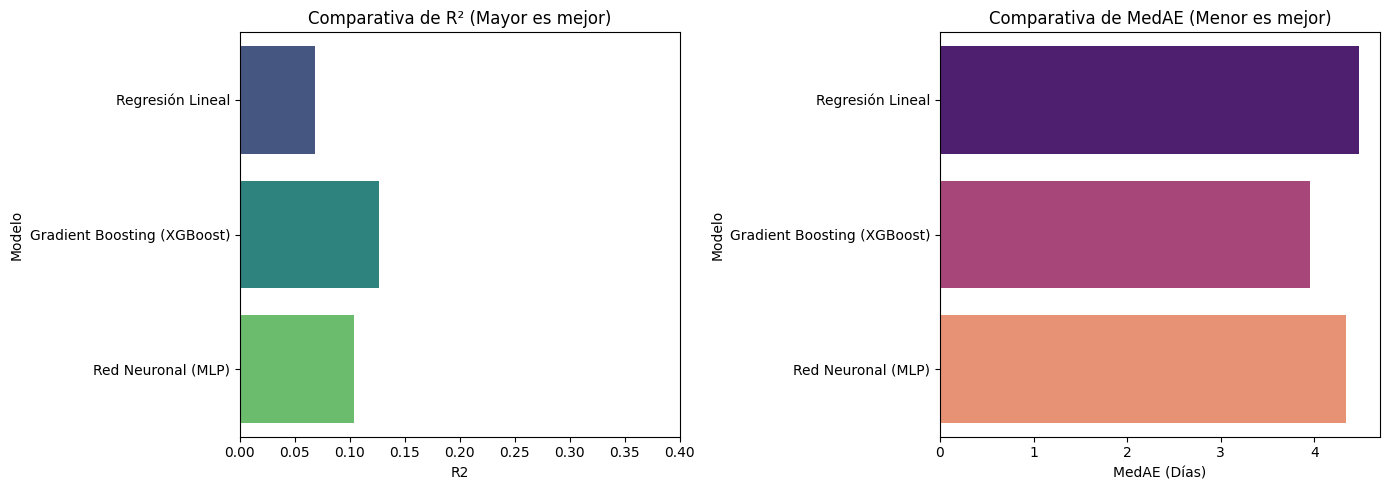

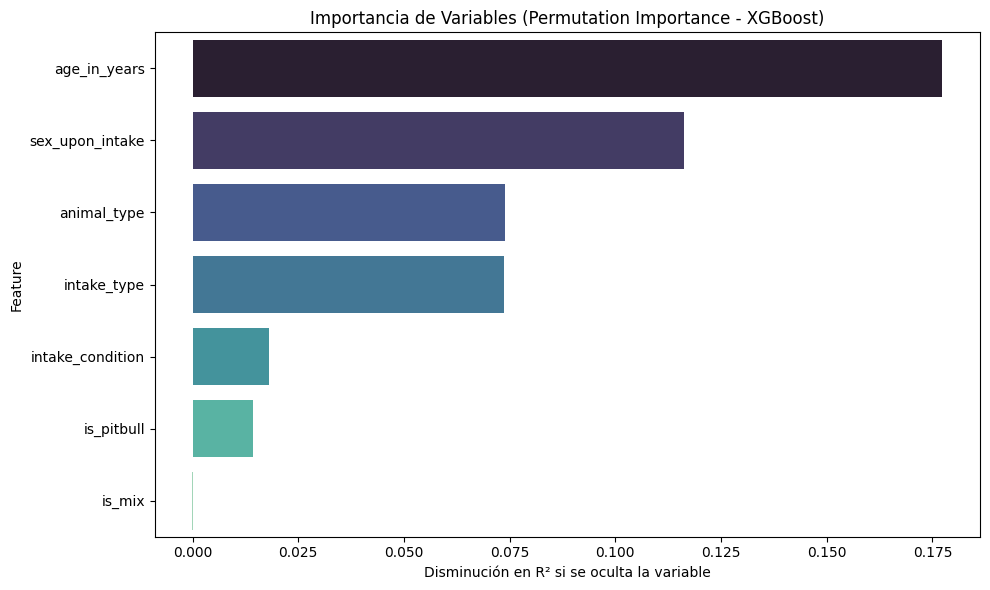

[
  {
    "Modelo": "Regresi\u00f3n Lineal",
    "R2": 0.06809559266456511,
    "MedAE (D\u00edas)": 4.479064169052964,
    "RMSE (D\u00edas)": 28.314579518119785
  },
  {
    "Modelo": "Gradient Boosting (XGBoost)",
    "R2": 0.12667228421956567,
    "MedAE (D\u00edas)": 3.9599056131001804,
    "RMSE (D\u00edas)": 27.538236034606104
  },
  {
    "Modelo": "Red Neuronal (MLP)",
    "R2": 0.10379828426175819,
    "MedAE (D\u00edas)": 4.3449865842429904,
    "RMSE (D\u00edas)": 27.498711122718625
  }
]


: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

# 1. Preparar los datos
df = pd.read_csv("aac_intakes_outcomes.csv")
df['intake_datetime'] = pd.to_datetime(df['intake_datetime'])
df = df.sort_values('intake_datetime')

valid_intakes = ['Stray', 'Owner Surrender', 'Public Assist']
df_filtered = df[df['intake_type'].isin(valid_intakes)].copy()

df_filtered['is_mix'] = df_filtered['breed'].str.contains('Mix', case=False, na=False).astype(int)
df_filtered['is_pitbull'] = df_filtered['breed'].str.contains('Pit Bull', case=False, na=False).astype(int)
df_filtered['age_in_years'] = df_filtered['age_upon_intake_(years)'].fillna(0)

target = 'time_in_shelter_days'
df_filtered['target_log'] = np.log1p(df_filtered[target])

cutoff_date = '2017-01-01'
train = df_filtered[df_filtered['intake_datetime'] < cutoff_date].copy()
test = df_filtered[df_filtered['intake_datetime'] >= cutoff_date].copy()

categorical_features = ['animal_type', 'intake_type', 'intake_condition', 'sex_upon_intake']
numeric_features = ['age_in_years', 'is_mix', 'is_pitbull']

X_train = train[categorical_features + numeric_features]
y_train = train['target_log']
X_test = test[categorical_features + numeric_features]
y_test = test['target_log']
y_test_real = test[target]

# 2. Pipelines de Preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 3. Modelos
models = {
    'Regresión Lineal': LinearRegression(),
    'Gradient Boosting (XGBoost)': HistGradientBoostingRegressor(random_state=42, max_iter=150, max_depth=7, learning_rate=0.08),
    'Red Neuronal (MLP)': MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)
    
    y_pred_log = pipe.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)
    
    r2 = r2_score(y_test, y_pred_log) # R2 en el espacio logarítmico (donde entrenaron)
    medae = median_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    
    results.append({
        'Modelo': name,
        'R2': r2,
        'MedAE (Días)': medae,
        'RMSE (Días)': rmse
    })
    
    # Guardar el modelo ganador para la explicabilidad
    if name == 'Gradient Boosting (XGBoost)':
        best_model = pipe

results_df = pd.DataFrame(results)

# 4. Gráfica de Comparativa
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Corrección de Seaborn: Asignar 'Modelo' a hue y desactivar la leyenda
sns.barplot(x='R2', y='Modelo', data=results_df, hue='Modelo', palette='viridis', legend=False)
plt.title('Comparativa de R² (Mayor es mejor)')
plt.xlim(0, 0.4)

plt.subplot(1, 2, 2)
sns.barplot(x='MedAE (Días)', y='Modelo', data=results_df, hue='Modelo', palette='magma', legend=False)
plt.title('Comparativa de MedAE (Menor es mejor)')

plt.tight_layout()
plt.show()

# 5. Explicabilidad (Permutation Importance en el mejor modelo)
# Extraemos los nombres de las columnas despues del OneHotEncoding
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features_names)

# Para Permutation Importance usamos el dataset ya preprocesado o pasamos los datos brutos por el pipeline
r = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

imp_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': r.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, hue='Feature', palette='mako', legend=False)
plt.title('Importancia de Variables (Permutation Importance - XGBoost)')
plt.xlabel('Disminución en R² si se oculta la variable')
plt.tight_layout()
plt.show()

import json
print(json.dumps(results_df.to_dict(orient='records'), indent=2))